In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None
)

column_names = [
    "Engine_ID",
    "Cycle",
    "Operational_Setting_1",
    "Operational_Setting_2",
    "Operational_Setting_3",
]

for i in range(1,22):
    column_names.append(f"Sensor_{i}")

df.columns = column_names

# Objective

The objective of this notebook is to evaluate the overall quality of the dataset before performing exploratory analysis.

The profiling process helps identify:

- Missing values
- Duplicate records
- Constant features
- Low variance features
- Statistical characteristics
- Sensor distributions

These findings will guide data cleaning and feature engineering in later stages.

In [5]:
df.isnull().sum()

Engine_ID                0
Cycle                    0
Operational_Setting_1    0
Operational_Setting_2    0
Operational_Setting_3    0
Sensor_1                 0
Sensor_2                 0
Sensor_3                 0
Sensor_4                 0
Sensor_5                 0
Sensor_6                 0
Sensor_7                 0
Sensor_8                 0
Sensor_9                 0
Sensor_10                0
Sensor_11                0
Sensor_12                0
Sensor_13                0
Sensor_14                0
Sensor_15                0
Sensor_16                0
Sensor_17                0
Sensor_18                0
Sensor_19                0
Sensor_20                0
Sensor_21                0
dtype: int64

### Observation

No missing values were detected.

The dataset is complete and suitable for further analysis.

In [6]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were identified.

Each row represents a unique engine cycle observation.

In [7]:
constant_features = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_features.append(col)

constant_features

['Operational_Setting_3',
 'Sensor_1',
 'Sensor_5',
 'Sensor_10',
 'Sensor_16',
 'Sensor_18',
 'Sensor_19']

### Observation

Constant features, if present, should be removed because they do not contribute useful information for analysis or predictive modeling.

In [8]:
df.var(numeric_only=True).sort_values()

Sensor_1                 0.000000e+00
Operational_Setting_3    0.000000e+00
Sensor_10                0.000000e+00
Sensor_18                0.000000e+00
Sensor_19                0.000000e+00
Sensor_16                1.203765e-35
Sensor_5                 2.840037e-29
Operational_Setting_2    8.588541e-08
Sensor_6                 1.929279e-06
Operational_Setting_1    4.784340e-06
Sensor_15                1.406628e-03
Sensor_8                 5.038938e-03
Sensor_13                5.172330e-03
Sensor_21                1.171825e-02
Sensor_20                3.266927e-02
Sensor_11                7.133568e-02
Sensor_2                 2.500533e-01
Sensor_12                5.439850e-01
Sensor_7                 7.833883e-01
Sensor_17                2.398667e+00
Sensor_3                 3.759099e+01
Sensor_4                 8.101089e+01
Sensor_14                3.639005e+02
Sensor_9                 4.876536e+02
Engine_ID                8.542545e+02
Cycle                    4.744591e+03
dtype: float

### Observation

Features with extremely low variance may contribute little information and will be evaluated during feature engineering.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine_ID,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
Cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
Operational_Setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
Operational_Setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
Operational_Setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
Sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
Sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
Sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
Sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
Sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


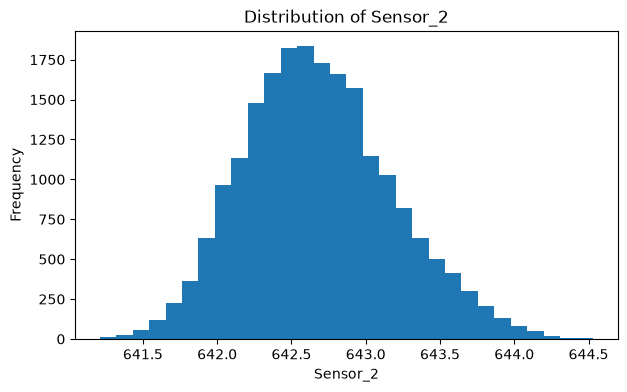

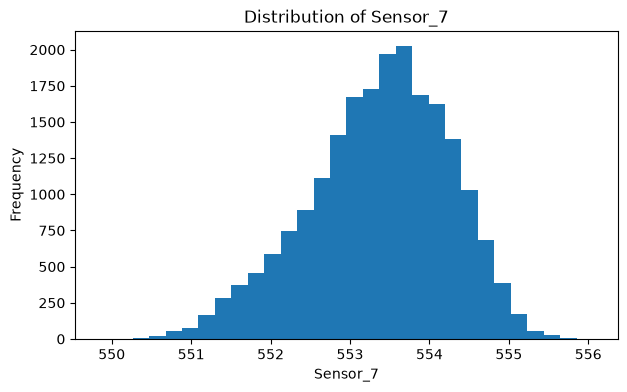

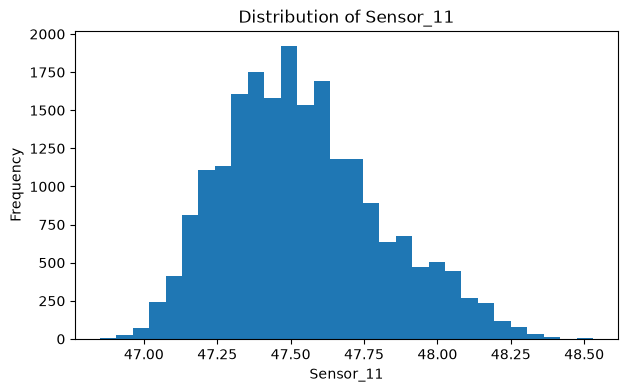

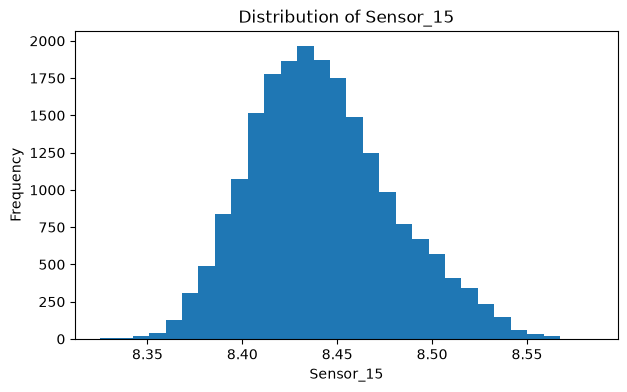

In [14]:
sensors = ["Sensor_2", "Sensor_7", "Sensor_11", "Sensor_15"]

for sensor in sensors:
    plt.figure(figsize=(7,4))
    plt.hist(df[sensor], bins=30)
    plt.title(f"Distribution of {sensor}")
    plt.xlabel(sensor)
    plt.ylabel("Frequency")
    plt.show()

Sensor 2 shows a roughly continuous distribution with no obvious gaps. Additional sensor analysis is required to determine whether this behavior changes as engines degrade.

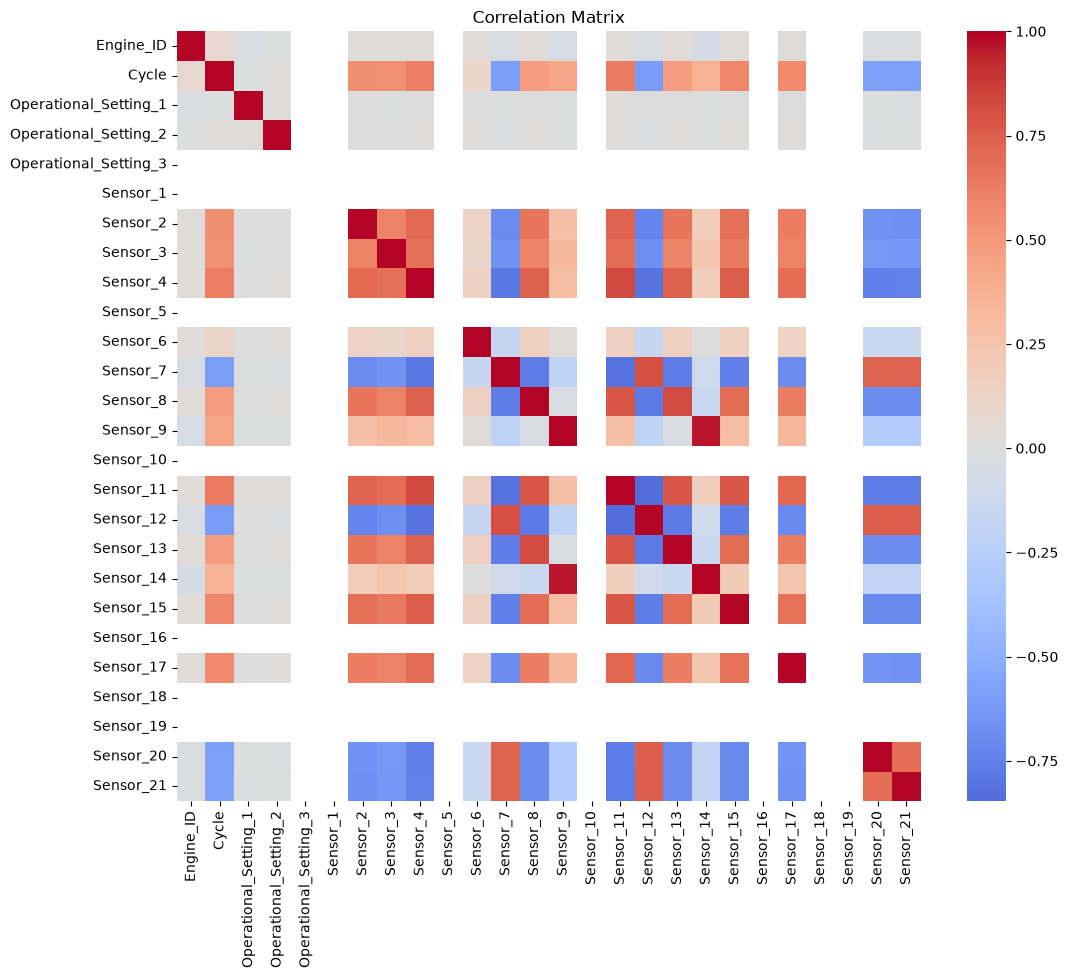

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

| Check                 | Status | Remarks                               |
| --------------------- | ------ | ------------------------------------- |
| Missing Values        | ✅      | No missing values detected            |
| Duplicate Records     | ✅      | No duplicate rows                     |
| Constant Features     | ⚠️     | 7 constant features identified        |
| Low Variance Features | ⚠️     | To be evaluated during cleaning       |
| Statistical Summary   | ✅      | Generated                             |
| Distribution Analysis | ✅      | Initial sensor distributions reviewed |
| Correlation Analysis  | ✅      | Sensor relationships identified       |
